In [ ]:
import pandas as pd
import re
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Path to your file
file_path = 'amazon-meta.txt'  # ← replace this with the actual file path

# Containers
ids = []
titles = []
avg_ratings = []
product_types = []
subcategories = []

with open(file_path, 'r', encoding='utf-8') as f:
    block = ""
    for line in f:
        if line.startswith("Id:"):
            if block:
                # Process previous block
                id_match = re.search(r"Id:\s+(\d+)", block)
                title_match = re.search(r"title:\s*(.*)", block)
                rating_match = re.search(r"avg rating:\s*([\d.]+)", block)
                categories = re.findall(r'\|(.+?)\n', block)

                # Find first valid Books category path
                valid_path = next((c for c in categories if c.startswith("Books[")), None)

                if valid_path:
                    segments = valid_path.split("|")
                    if len(segments) >= 3:
                        product_types.append(segments[0].split("[")[0])
                        subcategories.append(segments[2].split("[")[0])
                    else:
                        product_types.append(None)
                        subcategories.append(None)

                    ids.append(int(id_match.group(1)) if id_match else None)
                    titles.append(title_match.group(1).strip() if title_match else None)
                    avg_ratings.append(float(rating_match.group(1)) if rating_match else None)

            block = line
        else:
            block += line

    # Final block
    if block:
        id_match = re.search(r"Id:\s+(\d+)", block)
        title_match = re.search(r"title:\s*(.*)", block)
        rating_match = re.search(r"avg rating:\s*([\d.]+)", block)
        categories = re.findall(r'\|(.+?)\n', block)

        valid_path = next((c for c in categories if c.startswith("Books[")), None)

        if valid_path:
            segments = valid_path.split("|")
            if len(segments) >= 3:
                product_types.append(segments[0].split("[")[0])
                subcategories.append(segments[2].split("[")[0])
            else:
                product_types.append(None)
                subcategories.append(None)

            ids.append(int(id_match.group(1)) if id_match else None)
            titles.append(title_match.group(1).strip() if title_match else None)
            avg_ratings.append(float(rating_match.group(1)) if rating_match else None)

# Create DataFrame
df = pd.DataFrame({
    'Id': ids,
    'Title': titles,
    'Average Rating': avg_ratings,
    'Product Type': product_types,
    'Subcategory': subcategories
})

# Filter only Books
df = df[df['Product Type'] == 'Books'].reset_index(drop=True)

# Show the result
print(df.head())


   Id                                              Title  Average Rating  \
0   1            Patterns of Preaching: A Sermon Sampler             5.0   
1   2                         Candlemas: Feast of Flames             4.5   
2   3   World War II Allied Fighter Planes Trading Cards             5.0   
3   4  Life Application Bible Commentary: 1 and 2 Tim...             4.0   
4   5    Prayers That Avail Much for Business: Executive             0.0   

  Product Type              Subcategory  
0        Books  Religion & Spirituality  
1        Books  Religion & Spirituality  
2        Books            Home & Garden  
3        Books  Religion & Spirituality  
4        Books  Religion & Spirituality  


In [2]:
df = df[df['Average Rating'].notna() & (df['Average Rating'] != 0)].reset_index(drop=True)
print(df.head())
print(df['Average Rating'].describe())

   Id                                              Title  Average Rating  \
0   1            Patterns of Preaching: A Sermon Sampler             5.0   
1   2                         Candlemas: Feast of Flames             4.5   
2   3   World War II Allied Fighter Planes Trading Cards             5.0   
3   4  Life Application Bible Commentary: 1 and 2 Tim...             4.0   
4   6  How the Other Half Lives: Studies Among the Te...             4.0   

  Product Type              Subcategory  
0        Books  Religion & Spirituality  
1        Books  Religion & Spirituality  
2        Books            Home & Garden  
3        Books  Religion & Spirituality  
4        Books       Arts & Photography  
count    278315.000000
mean          4.315991
std           0.753381
min           1.000000
25%           4.000000
50%           4.500000
75%           5.000000
max           5.000000
Name: Average Rating, dtype: float64


In [3]:
df.to_csv('amazon_metadata.csv', index=False)

In [5]:
# Load metadata
meta_df = pd.read_csv('amazon_metadata.csv')

# Ensure IDs are strings (in case graph uses int format, convert later if needed)
meta_df['Id'] = meta_df['Id'].astype(str)

# Create a mapping: product ID -> metadata dict
meta_dict = meta_df.set_index('Id').to_dict(orient='index')

# Load edge list (co-purchase network)
edges = []
with open('Amazon0302.txt', 'r') as f:
    for line in f:
        if line.startswith('#'):
            continue  # Skip comment lines
        src, dst = line.strip().split()
        edges.append((src, dst))  # keep as strings to match metadata

# Build directed graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Attach metadata to nodes
for node in G.nodes:
    if node in meta_dict:
        nx.set_node_attributes(G, {node: meta_dict[node]})

# Optional: Remove nodes without metadata
G = G.subgraph([n for n in G.nodes if n in meta_dict]).copy()

# Quick check

print("Sample node with attributes:\n", G.nodes[list(G.nodes)[0]])

Sample node with attributes:
 {'Title': 'A Crash Course to Learn the Devanagari Script (For Hindi, Marathi and Sanskrit Languages)', 'Average Rating': 4.0, 'Product Type': 'Books', 'Subcategory': 'Religion & Spirituality'}


In [6]:
# Filter nodes with rating of 5
nodes_with_rating_5 = [n for n, attr in G.nodes(data=True) if attr.get('Average Rating') == 5.0]
G_rating_5 = G.subgraph(nodes_with_rating_5).copy()

print(f"Number of nodes with rating 5: {G_rating_5.number_of_nodes()}")
print(f"Number of edges: {G_rating_5.number_of_edges()}")

Number of nodes with rating 5: 48222
Number of edges: 42106


In [7]:
# Keep only the first 10,000 nodes in G and their edges
first_10000_nodes = list(G.nodes)[:10000]
G_10k = G.subgraph(first_10000_nodes).copy()

print(f"Number of nodes in G_10k: {G_10k.number_of_nodes()}")
print(f"Number of edges in G_10k: {G_10k.number_of_edges()}")

Number of nodes in G_10k: 10000
Number of edges in G_10k: 1761


In [8]:
from networkx.algorithms import community

# Use the greedy modularity communities algorithm (works for undirected graphs)
G_undirected = G.to_undirected()
communities = list(community.greedy_modularity_communities(G_undirected))

# Limit to 100 communities
communities = communities[:100]

print(f"Number of communities found (limited): {len(communities)}")
print(f"Size of first 5 communities: {[len(c) for c in communities[:5]]}")

Number of communities found (limited): 100
Size of first 5 communities: [7039, 6965, 6731, 6025, 5117]


In [9]:
[len(c) for c in communities[:30]]

[7039,
 6965,
 6731,
 6025,
 5117,
 3920,
 3268,
 2646,
 2280,
 2186,
 1840,
 1784,
 1749,
 1675,
 1558,
 1437,
 1399,
 1365,
 1357,
 1305,
 1302,
 1235,
 1223,
 1216,
 1153,
 1107,
 1101,
 1048,
 1037,
 981]

In [10]:
# Calculate transitivity (global clustering coefficient)
transitivity = nx.transitivity(G_undirected)

# Calculate average clustering coefficient
avg_clustering = nx.average_clustering(G_undirected)

print(f"Transitivity (global clustering coefficient): {transitivity}")
print(f"Average clustering coefficient: {avg_clustering}")

Transitivity (global clustering coefficient): 0.23027570837312958
Average clustering coefficient: 0.35411793874623526


In [11]:
# Aggregate community info into a DataFrame
community_data = []
for idx, comm in enumerate(communities):
    for node in comm:
        meta = meta_dict.get(node)
        if meta:
            community_data.append({
                'Community': idx,
                'Id': node,
                'Subcategory': meta.get('Subcategory', None)
            })

community_df = pd.DataFrame(community_data)

# Show the distribution of subcategories in each community
category_distribution = community_df.groupby(['Community', 'Subcategory']).size().unstack(fill_value=0)

# Display the first 10 communities' category distributions
category_distribution.head(10)

Subcategory,Accessories,Arts & Photography,Bargain Books,Biographies & Memoirs,Book Clubs,Books on CD,Books on Tape,Boxed Sets,Business & Investing,Calendars,...,Romance,Science,Science Fiction & Fantasy,Sheet Music & Scores,Sports,Teens,Travel,jp-unknown1,jp-unknown2,jp-unknown3
Community,,,,,,,,,,,,,,,,,,,,,
0,1,267,21,372,0,1,150,0,496,0,...,88,190,121,2,76,11,106,24,21,10
1,1,240,23,339,0,3,144,0,506,0,...,108,187,134,3,91,6,107,21,20,4
2,3,254,31,295,0,3,157,0,454,0,...,97,203,139,1,84,15,133,16,22,4
3,2,250,18,275,0,2,116,0,401,0,...,90,182,115,1,76,7,84,17,26,7
4,4,178,23,235,0,2,120,0,351,0,...,59,170,101,2,63,7,88,15,23,9
5,2,162,10,172,0,1,77,0,252,0,...,53,112,59,0,46,6,53,11,7,1
6,1,120,19,165,0,0,63,0,205,0,...,44,110,61,1,50,3,50,12,6,1
7,2,92,9,105,0,0,51,0,170,0,...,38,96,33,1,25,1,42,12,7,2
8,2,75,7,102,0,0,43,0,184,0,...,32,61,38,0,24,4,33,11,8,2


In [12]:
# Find the top 3 most frequent subcategories in each community
top3_subcategories = (
    community_df.groupby('Community')['Subcategory']
    .apply(lambda x: x.value_counts().head(3).index.tolist())
)

# Map the top 3 subcategories back to each row in community_df
community_df['Top 3 Subcategories'] = community_df['Community'].map(top3_subcategories)

# Show the updated DataFrame
community_df.head()

,Community,Id,Subcategory,Top 3 Subcategories
0,0,243479,Reference,"[Children's Books, Literature & Fiction, Busin..."
1,0,74060,Mystery & Thrillers,"[Children's Books, Literature & Fiction, Busin..."
2,0,15157,Nonfiction,"[Children's Books, Literature & Fiction, Busin..."
3,0,17519,Children's Books,"[Children's Books, Literature & Fiction, Busin..."
4,0,18460,Business & Investing,"[Children's Books, Literature & Fiction, Busin..."


In [13]:
community_df

,Community,Id,Subcategory,Top 3 Subcategories
0,0,243479,Reference,"[Children's Books, Literature & Fiction, Busin..."
1,0,74060,Mystery & Thrillers,"[Children's Books, Literature & Fiction, Busin..."
2,0,15157,Nonfiction,"[Children's Books, Literature & Fiction, Busin..."
3,0,17519,Children's Books,"[Children's Books, Literature & Fiction, Busin..."
4,0,18460,Business & Investing,"[Children's Books, Literature & Fiction, Busin..."
...,...,...,...,...
99186,99,3838,Religion & Spirituality,"[Business & Investing, Children's Books, Relig..."
99187,99,236224,Religion & Spirituality,"[Business & Investing, Children's Books, Relig..."
99188,99,565,Religion & Spirituality,"[Business & Investing, Children's Books, Relig..."
99189,99,240459,Religion & Spirituality,"[Business & Investing, Children's Books, Relig..."


In [ ]:
# This code takes too long to run, so we will not execute it here.

# Compute centralities
degree_centrality = nx.degree_centrality(G)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Create a DataFrame of top central nodes
centrality_df = pd.DataFrame({
    'Node': list(degree_centrality.keys()),
    'Degree': list(degree_centrality.values()),
    'In-Degree': list(in_degree_centrality.values()),
    'Out-Degree': list(out_degree_centrality.values()),
    'Betweenness': list(betweenness_centrality.values()),
    'Closeness': list(closeness_centrality.values())
})

# Merge with metadata for titles
centrality_df['Title'] = centrality_df['Node'].map(lambda x: meta_dict.get(x, {}).get('Title', 'Unknown'))

# Sort by Degree
top_central = centrality_df.sort_values(by='Degree', ascending=False).head(10)
top_central

In [15]:
largest_cc = max(nx.weakly_connected_components(G), key=len)
print("Size of largest connected component:", len(largest_cc))

Size of largest connected component: 110484


In [ ]:
# This code takes too long to run, so we will not execute it here.

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos,
        node_size=10,
        node_color='skyblue',
        edge_color='gray',
        with_labels=False,
        alpha=0.6)
plt.title("Amazon Books Co-Purchase Network (Simplified View)")
plt.show()

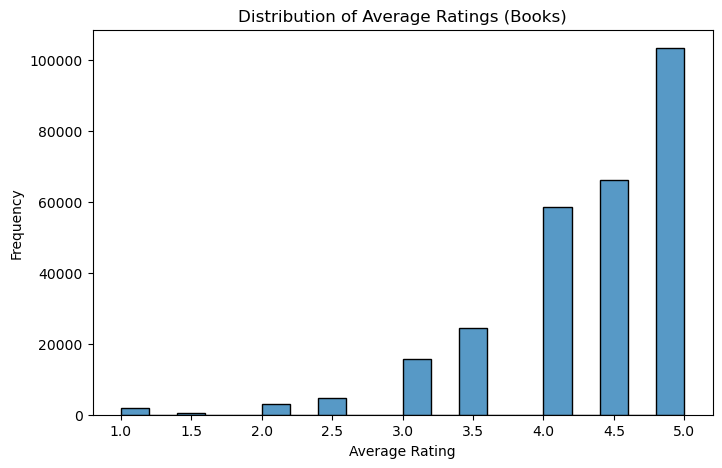

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(meta_df['Average Rating'], bins=20, kde=False)
plt.title("Distribution of Average Ratings (Books)")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()